### Impact of Circuit Depth on the Performance of QAOA
The first objective of this work is to systematically evaluate the influence of circuit depth in the QAOA. In particular, we investigate how increasing the number of QAOA layers ($p=1,2,3,4$) affects both the quality of the obtained solutions and the computational cost of the algorithm.

To conduct this study, we consider the Max-Cut Problem. The algorithm is applied to graphs of different sizes containing 8, 10, and 12 nodes, allowing us to analyze how circuit depth impacts performance as the problem size increases.


### Import Libraries

In [1]:
import pennylane as qml 
from pennylane import numpy as np 
import time 
import matplotlib.pyplot as plt 
import networkx as nx 

np.random.seed(42)

C:\Users\Probook\anaconda3\Lib\site-packages\pennylane\__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


### Define 3 Graphs: 8, 10, 12 nodes

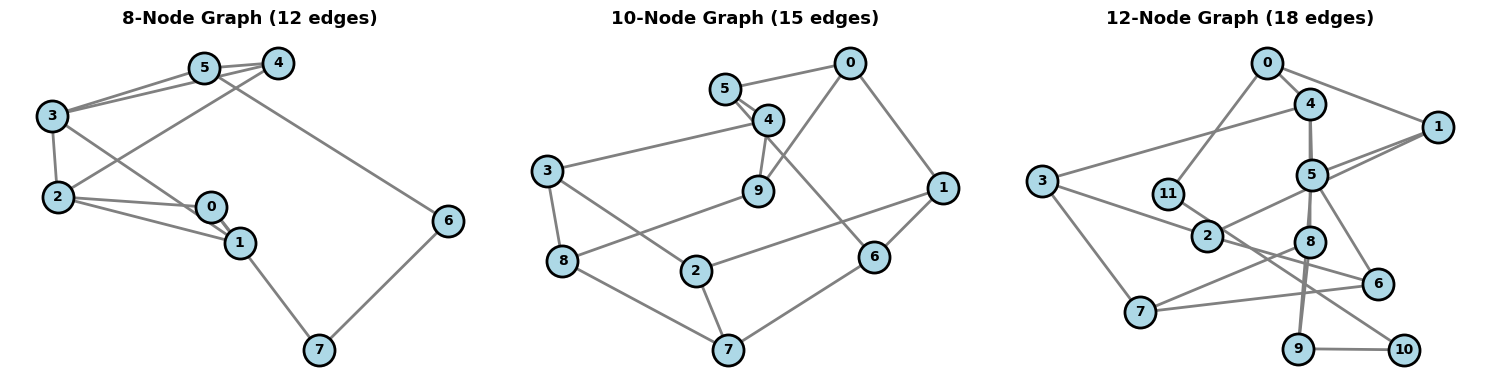

In [23]:
graphs = {
    8: [(0,1), (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,0), 
        (0,2), (1,3), (2,4), (3,5)],  # 8-node graph
    
    10: [
    # Main cycle
    (0,1), (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,0),
    # Inner connections (symmetric)
    (0,5), (1,6), (2,7), (3,8), (4,9)
],  # 10-node graph
    
    12: [(0,1), (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,10), (10,11), (11,0),
         (0,4), (1,5), (2,6), (3,7), (4,8), (5,9)]  # 12-node graph
} 


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, n_wires in enumerate([8, 10, 12]):
    ax = axes[idx]
    
    # Create NetworkX graph
    G = nx.Graph()
    G.add_edges_from(graphs[n_wires])
    
    # Layout
    pos = nx.spring_layout(G, seed=42, k=1.5)
    
    # Draw
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                           node_size=500, edgecolors='black', 
                           linewidths=2, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, 
                            font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                           width=2, ax=ax)
    
    ax.set_title(f'{n_wires}-Node Graph ({len(graphs[n_wires])} edges)', 
                 fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print()

### Calculate optimal solution using Brute Force 
Before evaluating the performance of the QAOA, I first compute the exact optimal solution for each graph used in my experiments. To do this, I implement a brute-force search for the Max-Cut Problem.  
I generate all possible partitions of the graph nodes, which correspond to the $2^n$ possible bitstrings for a graph with $n$ nodes. For each partition, I calculate the number of edges that connect nodes belonging to different subsets, which represents the cut value. The partition that produces the highest number of such edges is considered the optimal Max-Cut.  
This step allows me to obtain the optimal cut value for each graph, which I later use as a reference to evaluate how close the QAOA solutions are to the optimal result.

In [25]:
def compute_optimal_cut(n_wires, graph):
    """Brute force search for optimal MaxCut"""
    best_cut = 0
    
    for partition in range(2**n_wires):
        # Convert partition number to bitstring
        bitstring = format(partition, f'0{n_wires}b')
        
        # Count cut edges
        cut = 0
        for edge in graph:
            if bitstring[edge[0]] != bitstring[edge[1]]:
                cut += 1
        
        if cut > best_cut:
            best_cut = cut
    
    return best_cut

# Calculate optimal cuts for all graphs
optimal_cuts = {}
print("Calculating optimal cuts")
for n_wires, graph in graphs.items():
    optimal_cuts[n_wires] = compute_optimal_cut(n_wires, graph)
    print(f"  {n_wires}-node graph: Optimal cut = {optimal_cuts[n_wires]}")

print()

Calculating optimal cuts
  8-node graph: Optimal cut = 10
  10-node graph: Optimal cut = 15
  12-node graph: Optimal cut = 16



### QAOA Functions 

In [27]:
def U_M(beta, n_wires):
    for wire in range(n_wires):
        qml.RX(2 * beta, wires=wire)

def U_C(gamma, graph):
    for edge in graph:
        qml.CNOT(wires=edge)
        qml.RZ(gamma, wires=edge[1])
        qml.CNOT(wires=edge)

def bitstring_to_int(bit_string_sample):
    return int(2 ** np.arange(len(bit_string_sample)) @ bit_string_sample[::-1])

### Main Expirement Loop

In [29]:
results = {}

# Loop over 3 graphs
for n_wires in [8, 10, 12]:
    graph = graphs[n_wires]
    optimal_cut = optimal_cuts[n_wires]
    
    results[n_wires] = {}
    
    # Create device for this graph size
    dev = qml.device("default.qubit", wires=n_wires)
    
    # Define circuit for this graph
    @qml.qnode(dev)
    def circuit(gammas, betas, return_samples=False):
        for wire in range(n_wires):
            qml.Hadamard(wires=wire)
        
        for gamma, beta in zip(gammas, betas):
            U_C(gamma, graph)
            U_M(beta, n_wires)
        
        if return_samples:
            return qml.sample()
        
        C = qml.sum(*(qml.Z(w1) @ qml.Z(w2) for w1, w2 in graph))
        return qml.expval(C)
    
    def objective(params):
        return -0.5 * (len(graph) - circuit(*params))
    
    # Loop over 4 depths: p=1,2,3,4
    for n_layers in [1, 2, 3, 4]:
        print(f"\n{'='*60}")
        print(f"Graph: {n_wires} nodes | Depth: p={n_layers}")
        print(f"{'='*60}")
        
        # Initialize parameters
        init_params = np.ones((2, n_layers), requires_grad=True)
        
        # Initialize optimizer
        opt = qml.AdagradOptimizer(stepsize=0.5)
        
        # Start timing
        start_time = time.time()
        
        # Optimize
        params = init_params.copy()
        steps = 200
        
        for i in range(steps):
            params = opt.step(objective, params)
            
            if (i + 1) % 10 == 0:
                print(f"Step {i+1:3d}: Objective = {-objective(params):.4f}")
        
        # End timing
        elapsed_time = time.time() - start_time
        
        # Get final cut value
        final_cut = -objective(params)
        
        # Calculate approximation ratio
        approx_ratio = final_cut / optimal_cut
        
        # Get circuit depth (estimate)
        circuit_depth = n_layers * (3 * len(graph) + n_wires)
        
        # Sample bitstrings with optimized parameters
        bitstrings = qml.set_shots(circuit, shots=100)(*params, return_samples=True)
        sampled_ints = [bitstring_to_int(string) for string in bitstrings]
        
        # Find most frequent bitstring
        counts = np.bincount(np.array(sampled_ints))
        most_freq_bit_string = np.argmax(counts)
        
        # Store results
        results[n_wires][n_layers] = {
            'approx_ratio': approx_ratio,
            'iterations': steps,
            'time': elapsed_time,
            'circuit_depth': circuit_depth,
            'final_cut': final_cut,
            'optimal_cut': optimal_cut,
            'params': params,
            'bitstrings': sampled_ints,
            'most_frequent': most_freq_bit_string
        }
        
        # Print summary
        print(f"\nResults:")
        print(f"  Final cut: {final_cut:.2f}")
        print(f"  Optimal cut: {optimal_cut}")
        print(f"  Approximation ratio: {approx_ratio:.4f} ({approx_ratio*100:.1f}%)")
        print(f"  Time: {elapsed_time:.2f}s")
        print(f"  Circuit depth: {circuit_depth}")
        print(f"  Most frequent bitstring: {most_freq_bit_string:0{n_wires}b}")

# RESULTS SUMMARY TABLE

print("\n" + "="*80)
print("SUMMARY TABLE - OBJECTIVE 1")
print("="*80)

for n_wires in [8, 10, 12]:
    print(f"\n{n_wires}-node graph (Optimal cut = {optimal_cuts[n_wires]}):")
    print("-"*80)
    print(f"{'p':<5} {'Approx Ratio':<15} {'Time (s)':<12} {'Iterations':<12} {'Circuit Depth':<15}")
    print("-"*80)
    
    for n_layers in [1, 2, 3, 4]:
        r = results[n_wires][n_layers]
        print(f"{n_layers:<5} {r['approx_ratio']:<15.4f} {r['time']:<12.2f} "
              f"{r['iterations']:<12} {r['circuit_depth']:<15}")

print("\n" + "="*80)




Graph: 8 nodes | Depth: p=1
Step  10: Objective = 7.7813
Step  20: Objective = 7.7822
Step  30: Objective = 7.7822
Step  40: Objective = 7.7822
Step  50: Objective = 7.7822
Step  60: Objective = 7.7822
Step  70: Objective = 7.7822
Step  80: Objective = 7.7822
Step  90: Objective = 7.7822
Step 100: Objective = 7.7822
Step 110: Objective = 7.7822
Step 120: Objective = 7.7822
Step 130: Objective = 7.7822
Step 140: Objective = 7.7822
Step 150: Objective = 7.7822
Step 160: Objective = 7.7822
Step 170: Objective = 7.7822
Step 180: Objective = 7.7822
Step 190: Objective = 7.7822
Step 200: Objective = 7.7822

Results:
  Final cut: 7.78
  Optimal cut: 10
  Approximation ratio: 0.7782 (77.8%)
  Time: 13.33s
  Circuit depth: 44
  Most frequent bitstring: 11001110

Graph: 8 nodes | Depth: p=2
Step  10: Objective = 8.3241
Step  20: Objective = 8.3700
Step  30: Objective = 8.3701
Step  40: Objective = 8.3702
Step  50: Objective = 8.3702
Step  60: Objective = 8.3702
Step  70: Objective = 8.3702
Step

### VISUALIZATION

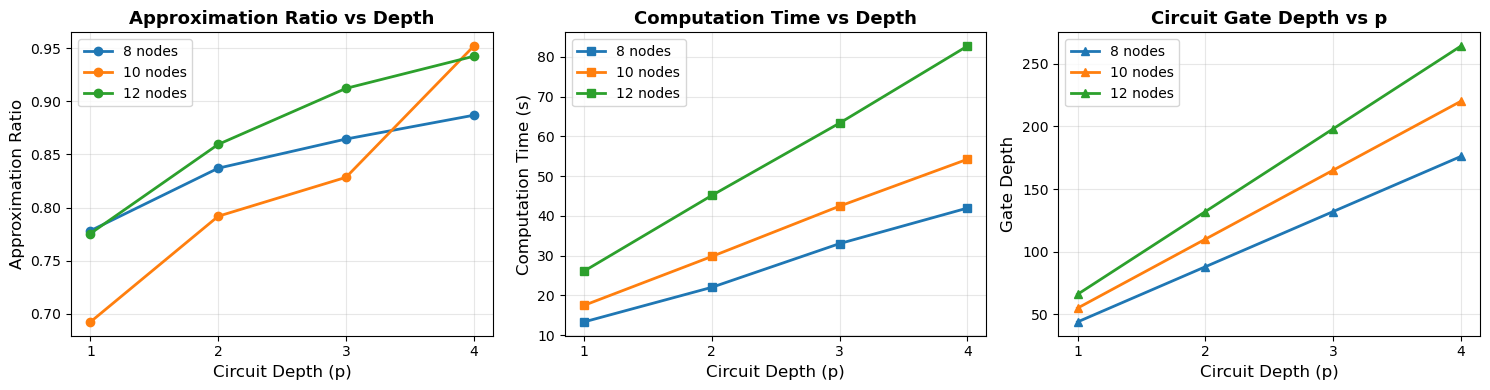

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Approximation Ratio vs p
for n_wires in [8, 10, 12]:
    p_values = [1, 2, 3, 4]
    ratios = [results[n_wires][p]['approx_ratio'] for p in p_values]
    axes[0].plot(p_values, ratios, marker='o', label=f'{n_wires} nodes', linewidth=2)

axes[0].set_xlabel('Circuit Depth (p)', fontsize=12)
axes[0].set_ylabel('Approximation Ratio', fontsize=12)
axes[0].set_title('Approximation Ratio vs Depth', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks([1, 2, 3, 4])

# Plot 2: Time vs p
for n_wires in [8, 10, 12]:
    p_values = [1, 2, 3, 4]
    times = [results[n_wires][p]['time'] for p in p_values]
    axes[1].plot(p_values, times, marker='s', label=f'{n_wires} nodes', linewidth=2)

axes[1].set_xlabel('Circuit Depth (p)', fontsize=12)
axes[1].set_ylabel('Computation Time (s)', fontsize=12)
axes[1].set_title('Computation Time vs Depth', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks([1, 2, 3, 4])

# Plot 3: Circuit Depth vs p
for n_wires in [8, 10, 12]:
    p_values = [1, 2, 3, 4]
    depths = [results[n_wires][p]['circuit_depth'] for p in p_values]
    axes[2].plot(p_values, depths, marker='^', label=f'{n_wires} nodes', linewidth=2)

axes[2].set_xlabel('Circuit Depth (p)', fontsize=12)
axes[2].set_ylabel('Gate Depth', fontsize=12)
axes[2].set_title('Circuit Gate Depth vs p', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks([1, 2, 3, 4])

plt.tight_layout()
plt.show()



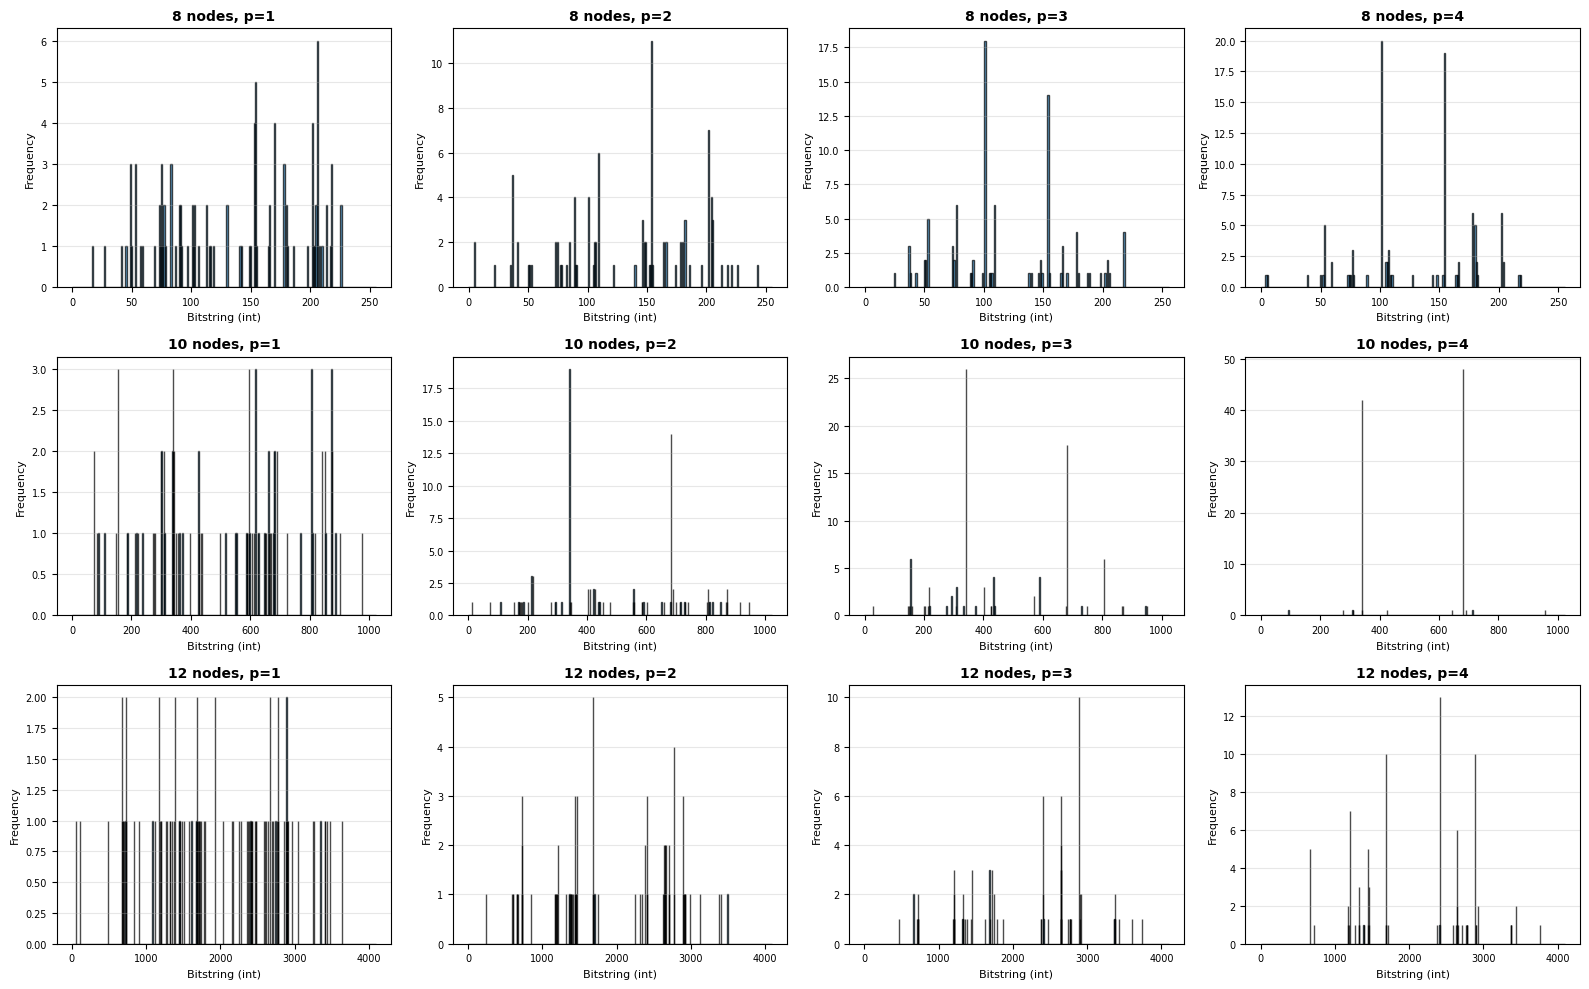

OBJECTIVE 01: 

8-node graph:
  p=1: 77.8% ratio, 13.3s, depth=44
  p=2: 83.7% ratio, 22.0s, depth=88
  p=3: 86.4% ratio, 33.0s, depth=132
  p=4: 88.7% ratio, 42.0s, depth=176

10-node graph:
  p=1: 69.2% ratio, 17.5s, depth=55
  p=2: 79.2% ratio, 29.8s, depth=110
  p=3: 82.8% ratio, 42.4s, depth=165
  p=4: 95.2% ratio, 54.2s, depth=220

12-node graph:
  p=1: 77.6% ratio, 26.1s, depth=66
  p=2: 85.9% ratio, 45.1s, depth=132
  p=3: 91.2% ratio, 63.3s, depth=198
  p=4: 94.2% ratio, 82.7s, depth=264


In [33]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for i, n_wires in enumerate([8, 10, 12]):
    for j, n_layers in enumerate([1, 2, 3, 4]):
        ax = axes[i, j]
        
        samples = results[n_wires][n_layers]['bitstrings']
        max_int = 2**n_wires - 1
        bins = np.arange(0, max_int + 2) - 0.5
        
        ax.hist(samples, bins=bins, edgecolor='black', alpha=0.7)
        ax.set_title(f'{n_wires} nodes, p={n_layers}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Bitstring (int)', fontsize=8)
        ax.set_ylabel('Frequency', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# FINAL SUMMARY

print("OBJECTIVE 01: ")

for n_wires in [8, 10, 12]:
    print(f"\n{n_wires}-node graph:")
    for p in [1, 2, 3, 4]:
        r = results[n_wires][p]
        print(f"  p={p}: {r['approx_ratio']:.1%} ratio, {r['time']:.1f}s, depth={r['circuit_depth']}")



## Higher p → better quality BUT more time + deeper circuits